In [7]:
#Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [10]:
df = pd.read_csv('data/water_potability.csv')
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [19]:
print(f"Số dòng của dữ liệu:{len(df)}")
print(f"Số tổng missing mỗi cột:\n{df.isnull().sum()}")


Số dòng của dữ liệu:3276
Số tổng missing mỗi cột:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [21]:
#Xử lý missing values bằng median
df_clean = df.fillna(df.median())
print(df_clean.isnull().sum())

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [25]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3276 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          3276 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3276 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [22]:
df_clean.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000
mean,7.074194,196.369496,22014.092526,7.122277,333.608364,426.205111,14.284970,66.407478,3.966786,0.390110
std,1.470040,32.879761,8768.570828,1.583085,36.143851,80.824064,3.308162,15.769958,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.277673,176.850538,15666.690297,6.127421,317.094638,365.734414,12.065801,56.647656,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,7.870050,216.667456,27332.762127,8.114887,350.385756,481.792304,16.557652,76.666609,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [23]:
df_clean.corr()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.075760,-0.082004,-0.031741,0.014178,0.017466,0.040240,0.003145,-0.036107,-0.003014
Hardness,0.075760,1.000000,-0.046899,-0.030054,-0.092833,-0.023915,0.003610,-0.012707,-0.014449,-0.013837
Solids,-0.082004,-0.046899,1.000000,-0.070148,-0.149747,0.013831,0.010242,-0.008799,0.019546,0.033743
Chloramines,-0.031741,-0.030054,-0.070148,1.000000,0.023762,-0.020486,-0.012653,0.016614,0.002363,0.023779
Sulfate,0.014178,-0.092833,-0.149747,0.023762,1.000000,-0.014182,0.027102,-0.025657,-0.009767,-0.020476
Conductivity,0.017466,-0.023915,0.013831,-0.020486,-0.014182,1.000000,0.020966,0.001184,0.005798,-0.008128
Organic_carbon,0.040240,0.003610,0.010242,-0.012653,0.027102,0.020966,1.000000,-0.012958,-0.027308,-0.030001
Trihalomethanes,0.003145,-0.012707,-0.008799,0.016614,-0.025657,0.001184,-0.012958,1.000000,-0.021487,0.006887
Turbidity,-0.036107,-0.014449,0.019546,0.002363,-0.009767,0.005798,-0.027308,-0.021487,1.000000,0.001581
Potability,-0.003014,-0.013837,0.033743,0.023779,-0.020476,-0.008128,-0.030001,0.006887,0.001581,1.000000


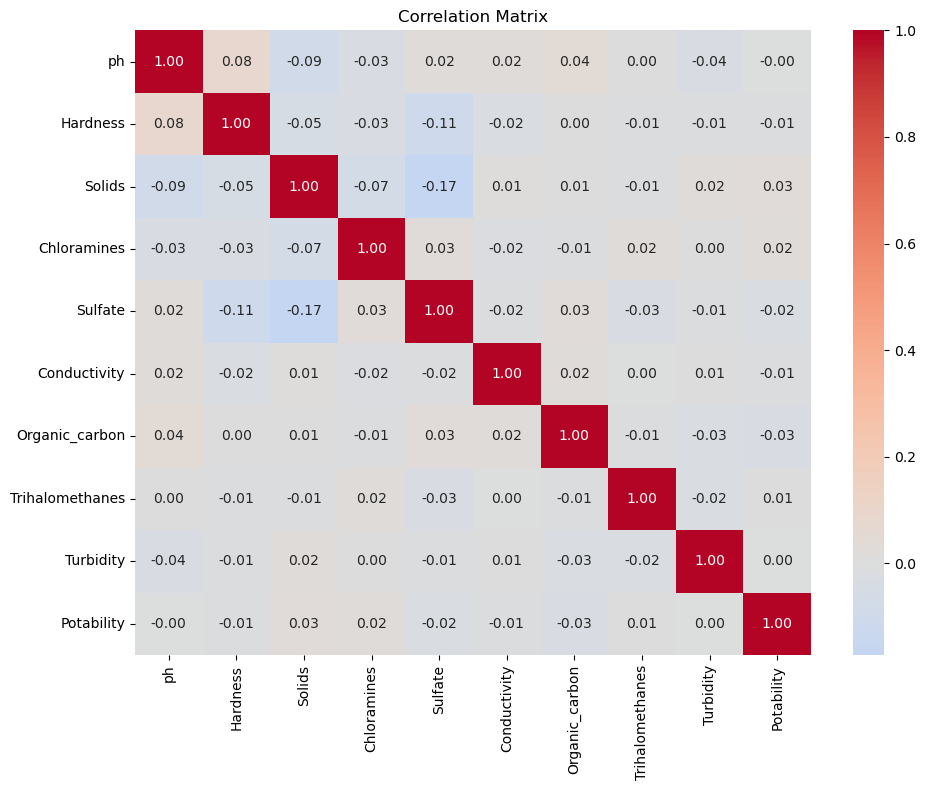

In [26]:
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

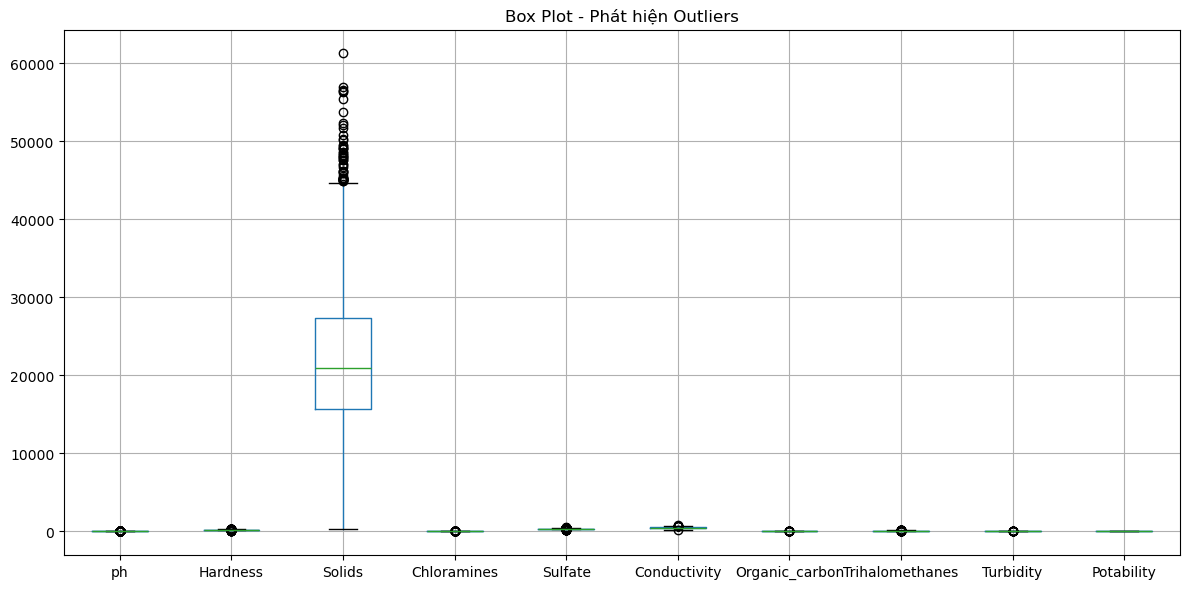

In [27]:
# Cách tìm các điểm outlier
# Visualize bằng box plot
plt.figure(figsize=(12, 6))
df_clean.boxplot()
plt.title('Box Plot - Phát hiện Outliers')
plt.tight_layout()
plt.show()

In [28]:
from scipy import stats

# Skewness của từng cột
skewness = df_clean.skew()
print("Skewness của từng cột:")
print(skewness)

# Giải thích:
# Skewness > 0.5: Right-skewed (lệch phải)
# Skewness < -0.5: Left-skewed (lệch trái)
# -0.5 to 0.5: Gần đối xứng

Skewness của từng cột:
ph                 0.041266
Hardness          -0.039342
Solids             0.621634
Chloramines       -0.012098
Sulfate           -0.027278
Conductivity       0.264490
Organic_carbon     0.025533
Trihalomethanes   -0.087289
Turbidity         -0.007817
Potability         0.450784
dtype: float64


<Figure size 1400x600 with 0 Axes>

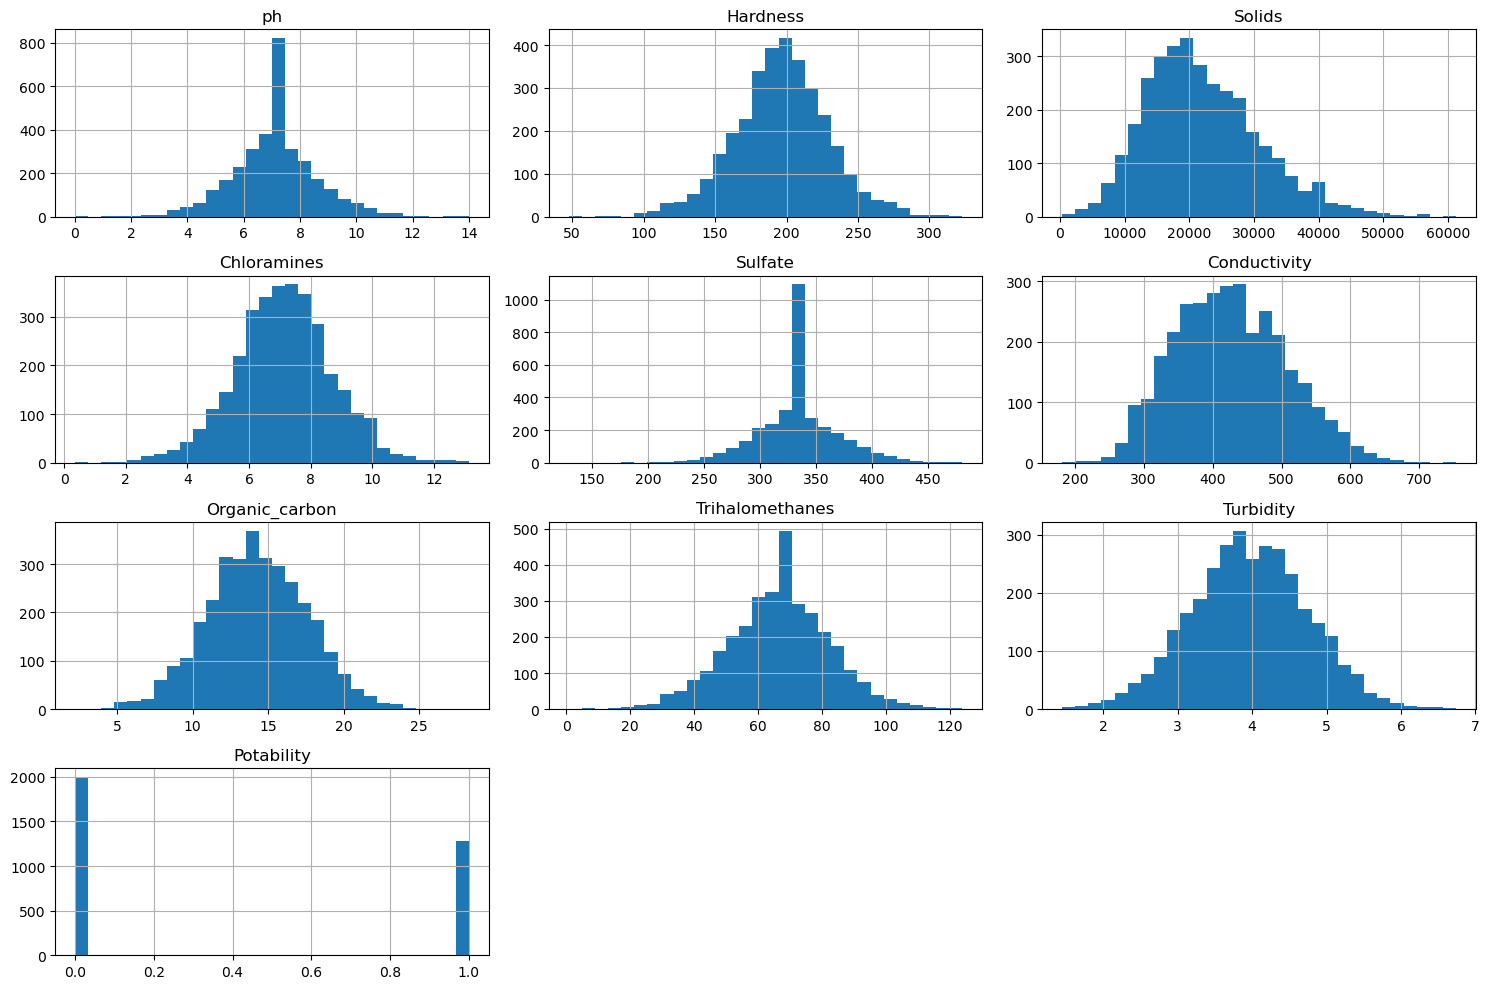

In [29]:
plt.figure(figsize=(14, 6))
df_clean.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

In [31]:
print("Distribution of Potability:")
print(df_clean['Potability'].value_counts())
print("\nPercentage:")
print(df_clean['Potability'].value_counts(normalize=True) * 100)

Distribution of Potability:
Potability
0    1998
1    1278
Name: count, dtype: int64

Percentage:
Potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64


In [33]:
# Chuẩn hoá dữ liệu
from sklearn.preprocessing import StandardScaler

# Tách X (features) và y (target)
X = df_clean.drop('Potability', axis=1)
y = df_clean['Potability']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled data:")
print(X_scaled.head())
print(f"\nMean: {X_scaled.mean()}")
print(f"Std: {X_scaled.std()}")

Scaled data:
         ph  Hardness    Solids  Chloramines   Sulfate  Conductivity  \
0 -0.025474  0.259195 -0.139471     0.112415  0.965957      1.708954   
1 -2.284717 -2.036414 -0.385987    -0.307694 -0.014799      2.062575   
2  0.697319  0.847665 -0.240047     1.360594 -0.014799     -0.094032   
3  0.845393  0.547651  0.000493     0.592008  0.644130     -0.778830   
4  1.372982 -0.464429 -0.460249    -0.363698 -0.649522     -0.343939   

   Organic_carbon  Trihalomethanes  Turbidity  
0       -1.180651         1.305434  -1.286298  
1        0.270597        -0.639186   0.684218  
2        0.781117         0.000800  -1.167365  
3        1.255134         2.152154   0.848412  
4       -0.824357        -2.182297   0.138786  

Mean: ph                 4.218576e-16
Hardness           1.024821e-15
Solids            -4.012528e-17
Chloramines        5.205441e-16
Sulfate           -2.260029e-15
Conductivity       1.708035e-16
Organic_carbon     2.385827e-17
Trihalomethanes   -2.646099e-16
Tur

In [34]:
from scipy.stats import pearsonr

# Tính correlation coefficient và p-value
corr_coef, p_value = pearsonr(df_clean['ph'], df_clean['Solids'])

print("Hypothesis Testing: pH vs Solids")
print("="*50)
print(f"Null Hypothesis: Increase in pH is associated with increase in Solids")
print(f"Alternate: No relation between pH and Solids")
print("="*50)
print(f"Correlation Coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value:.6f}")
print("="*50)

# Kết luận
alpha = 0.05
if p_value < alpha:
    print(f"✓ P-value ({p_value:.6f}) < {alpha}")
    print("→ Reject Null Hypothesis")
    print("→ Có mối quan hệ có ý nghĩa thống kê giữa pH và Solids")
else:
    print(f"✗ P-value ({p_value:.6f}) >= {alpha}")
    print("→ Fail to Reject Null Hypothesis")
    print("→ Không có mối quan hệ có ý nghĩa thống kê giữa pH và Solids")

Hypothesis Testing: pH vs Solids
Null Hypothesis: Increase in pH is associated with increase in Solids
Alternate: No relation between pH and Solids
Correlation Coefficient: -0.0820
P-value: 0.000003
✓ P-value (0.000003) < 0.05
→ Reject Null Hypothesis
→ Có mối quan hệ có ý nghĩa thống kê giữa pH và Solids


Feature Importance (Correlation with Potability):
Potability         1.000000
Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.006887
Turbidity          0.001581
ph                -0.003014
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.020476
Organic_carbon    -0.030001
Name: Potability, dtype: float64


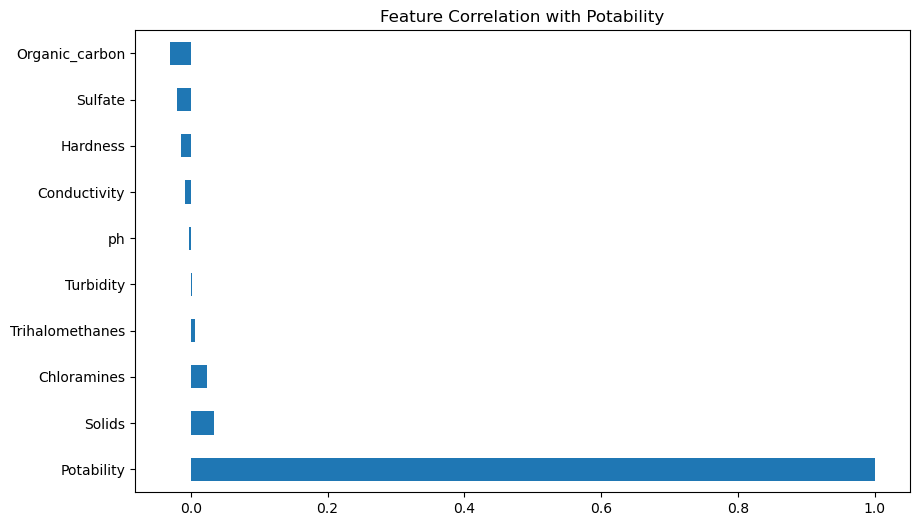

In [35]:
# Xem feature nào quan trọng nhất với Potability
corr_target = df_clean.corr()['Potability'].sort_values(ascending=False)
print("Feature Importance (Correlation with Potability):")
print(corr_target)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
corr_target.plot(kind='barh')
plt.title('Feature Correlation with Potability')
plt.show()

In [37]:
from sklearn.model_selection import train_test_split

# Chia 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Giữ tỉ lệ class như dataset gốc
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTrain class distribution: \n{y_train.value_counts()}")
print(f"\nTest class distribution: \n{y_test.value_counts()}")

Training set size: 2620
Test set size: 656

Train class distribution: 
Potability
0    1598
1    1022
Name: count, dtype: int64

Test class distribution: 
Potability
0    400
1    256
Name: count, dtype: int64


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Xây dựng model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Dự đoán
y_pred_lr = lr_model.predict(X_test)

# Đánh giá
print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")

Logistic Regression Results:
Accuracy: 0.6098
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000


c:\Users\ADMIN\miniconda3\envs\ml_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance)

Random Forest Results:
Accuracy: 0.6585
Precision: 0.6311
Recall: 0.3008
F1-Score: 0.4074

Feature Importance:
           Feature  Importance
0               ph    0.129132
4          Sulfate    0.127858
1         Hardness    0.121633
3      Chloramines    0.116048
2           Solids    0.111863
5     Conductivity    0.100752
8        Turbidity    0.099522
6   Organic_carbon    0.097521
7  Trihalomethanes    0.095672


In [41]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42, probability=True)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm):.4f}")

SVM Results:
Accuracy: 0.6707
Precision: 0.7041
Recall: 0.2695
F1-Score: 0.3898
